In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Model imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns',200)
%matplotlib inline

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
#Loading the data
path="data/For_modeling.csv.zip"

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
data = pd.read_csv(path, 
                  dtype={
                      'Duration': 'int8',
                      'Distance': 'int8',
                      'PLong': 'float32',
                      'PLatd': 'float32',
                      'DLong': 'float32',
                      'Haversine':'float32',
                      'Pmonth':'int8',
                      'Pday':'int8',
                      'Phour':'int8',
                      'Pmin':'int8',
                      'PDweek':'int8',
                      'Dmonth':'int8',
                      'Dday':'int8',
                      'Dhour':'int8',
                      'Dmin':'int8',
                      'DDweek':'int8',
                      'Temp':'float32',
                      'Precip':'float32',
                      'Wind':'float32',
                      'Solar':'float32',
                      'Snow':'float32',
                      'GroundTemp':'float32',
                      'Dust':'float32'
                  },index_col=0
                  
                  ).sample(frac=1)

#checking for data
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
761182,45,-74,37.650330,127.071602,37.626614,127.072754,2.639053,3,31,15,47,5,3,31,16,36,5,18.900000,0.0,3.7,28.0,2.09,0.0,24.799999,64.0
1883604,10,22,37.494106,126.982994,37.499413,126.999413,1.564090,5,15,23,20,1,5,15,23,31,1,24.799999,0.0,1.0,60.0,0.00,0.0,22.299999,37.0
8532625,54,68,37.582031,126.908997,37.548645,126.912827,3.727676,11,4,12,22,6,11,4,13,16,6,16.299999,0.0,2.9,33.0,2.13,0.0,22.900000,84.0
8172535,18,86,37.601299,126.935349,37.617855,126.922523,2.159988,10,25,11,29,3,10,25,11,49,3,16.400000,0.0,0.7,43.0,1.96,0.0,21.799999,70.0
669140,12,-112,37.510933,126.910225,37.494499,126.916527,1.910070,3,27,8,7,1,3,27,8,20,1,9.300000,0.0,0.6,62.0,0.25,0.0,8.500000,69.0
8177928,26,-20,37.513126,127.100960,37.532688,127.067497,3.666125,10,25,14,7,3,10,25,14,33,3,20.600000,0.0,1.4,31.0,1.70,0.0,24.700001,59.0
5875910,7,-96,37.531860,127.067192,37.528587,127.077873,1.009733,9,7,18,4,4,9,7,18,11,4,24.400000,0.0,2.4,34.0,0.84,0.0,24.100000,0.0
7092946,3,50,37.512939,126.934242,37.512939,126.934242,0.000000,10,2,18,55,1,10,2,18,59,1,19.200001,0.0,2.2,48.0,0.28,0.0,18.900000,27.0
2225890,49,-118,37.541363,127.017662,37.541363,127.017662,0.000000,5,27,20,3,6,5,27,20,52,6,20.600000,0.0,2.3,41.0,0.09,0.0,19.799999,24.0
3084753,7,-50,37.577995,126.891472,37.575069,126.899918,0.812320,6,19,17,9,1,6,19,17,17,1,25.100000,0.0,2.4,51.0,1.15,0.0,32.099998,28.0


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
#Resetting index
data = data.reset_index().drop(columns=['index'])
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
0,45,-74,37.650330,127.071602,37.626614,127.072754,2.639053,3,31,15,47,5,3,31,16,36,5,18.900000,0.0,3.7,28.0,2.09,0.0,24.799999,64.0
1,10,22,37.494106,126.982994,37.499413,126.999413,1.564090,5,15,23,20,1,5,15,23,31,1,24.799999,0.0,1.0,60.0,0.00,0.0,22.299999,37.0
2,54,68,37.582031,126.908997,37.548645,126.912827,3.727676,11,4,12,22,6,11,4,13,16,6,16.299999,0.0,2.9,33.0,2.13,0.0,22.900000,84.0
3,18,86,37.601299,126.935349,37.617855,126.922523,2.159988,10,25,11,29,3,10,25,11,49,3,16.400000,0.0,0.7,43.0,1.96,0.0,21.799999,70.0
4,12,-112,37.510933,126.910225,37.494499,126.916527,1.910070,3,27,8,7,1,3,27,8,20,1,9.300000,0.0,0.6,62.0,0.25,0.0,8.500000,69.0
5,26,-20,37.513126,127.100960,37.532688,127.067497,3.666125,10,25,14,7,3,10,25,14,33,3,20.600000,0.0,1.4,31.0,1.70,0.0,24.700001,59.0
6,7,-96,37.531860,127.067192,37.528587,127.077873,1.009733,9,7,18,4,4,9,7,18,11,4,24.400000,0.0,2.4,34.0,0.84,0.0,24.100000,0.0
7,3,50,37.512939,126.934242,37.512939,126.934242,0.000000,10,2,18,55,1,10,2,18,59,1,19.200001,0.0,2.2,48.0,0.28,0.0,18.900000,27.0
8,49,-118,37.541363,127.017662,37.541363,127.017662,0.000000,5,27,20,3,6,5,27,20,52,6,20.600000,0.0,2.3,41.0,0.09,0.0,19.799999,24.0
9,7,-50,37.577995,126.891472,37.575069,126.899918,0.812320,6,19,17,9,1,6,19,17,17,1,25.100000,0.0,2.4,51.0,1.15,0.0,32.099998,28.0


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
#Dropping value with haversine ==0
data= data[data['Haversine']!=0].reset_index().drop(columns=['index'])
#data.shape

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
#transforming all the negative distance to posiive distances

data["Distance"]=data['Distance'].apply(lambda x:abs(x))
data[data['Distance']<0].shape

(0, 25)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
#Dropping values with diatance is zero, that indicate trip was never occured or error in recordings or something
data = data[data['Distance']!=0].reset_index().drop(columns=['index'])
data[data['Distance']==0].shape

(0, 25)

<ipython-input-8-177cc7d25087>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_duration = data.groupby(data1)['Duration'].mean()


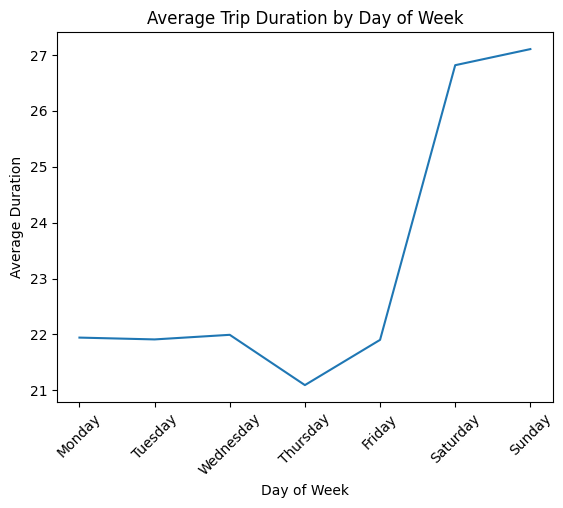

In [8]:
# --- [CELL 7]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# === BEFORE (original) ===
# #Average Trip Duration by Day of Week
# # Convert the 'PDweek' column to a day of the week name
# data1= pd.Categorical(data['PDweek'], categories=range(7), ordered=True)
# data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], inplace=True)
# 
# # Calculate the average trip duration for each day of the week
# average_duration = data1.groupby('DayOfWeek')['Duration'].mean()
# 
# # Create a line chart
# plt.plot(average_duration.index, average_duration.values)
# plt.xlabel('Day of Week')
# plt.ylabel('Average Duration')
# plt.title('Average Trip Duration by Day of Week')
# plt.xticks(rotation=45)
# plt.show()

# === AFTER (edited) ===
data1 = pd.Series(pd.Categorical(data['PDweek'], categories=range(7), ordered=True), name='DayOfWeek')
data1 = data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

average_duration = data.groupby(data1)['Duration'].mean()

plt.plot(average_duration.index, average_duration.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Duration')
plt.title('Average Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Behavioral test for day-of-week aggregation fix
expected_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
assert 'DayOfWeek' in data.columns, 'Expected DayOfWeek column to be created on data'
assert str(data['DayOfWeek'].dtype) == 'category', 'DayOfWeek should be categorical'
assert list(data['DayOfWeek'].cat.categories) == expected_days, 'DayOfWeek categories should be renamed to weekday names'
assert average_duration.index.name == 'DayOfWeek', 'Aggregation should group by DayOfWeek on data'
assert len(average_duration) == 7, 'Expected one aggregated value per weekday'

AssertionError: Expected DayOfWeek column to be created on data